# Example Data

In [1]:
import pandas as pd 
from chronos import Chronos2Pipeline
import datetime
import torch
import matplotlib.pyplot as plt

In [2]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [3]:
children = list(pipeline.model.children())

In [4]:
for idx, param in enumerate(children):
    print(f'Layer {idx}: {param.__class__.__name__}')
    print('------------------')

Layer 0: Embedding
------------------
Layer 1: ResidualBlock
------------------
Layer 2: Patch
------------------
Layer 3: InstanceNorm
------------------
Layer 4: Chronos2Encoder
------------------
Layer 5: ResidualBlock
------------------


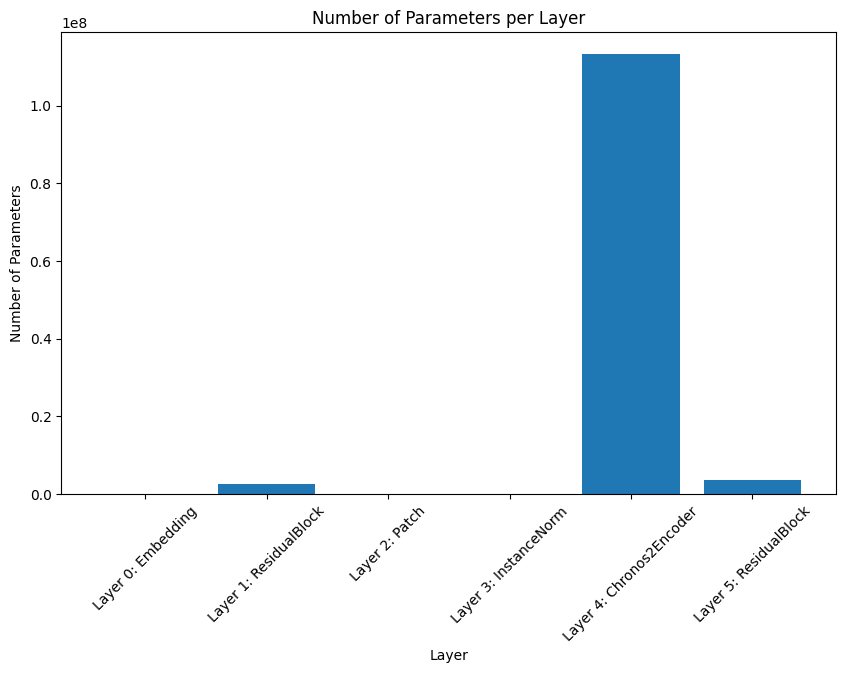

In [ ]:
# plot number of parameters per layer
layer_names = []
num_params = []
for idx, param in enumerate(pipeline.model.children()):
    layer_names.append(f'Layer {idx}: {param.__class__.__name__}')
    num_params.append(sum(p.numel() for p in param.parameters()))

# plot the number of parameters per layer
plt.figure(figsize=(10, 6))
plt.bar(layer_names, num_params)
plt.xlabel('Layer')
plt.ylabel('Number of Parameters')
plt.title('Number of Parameters per Layer')
plt.xticks(rotation=45)
plt.show()

In [6]:
for name, child in pipeline.model.named_modules():
    print(f'{name}: {child.__class__.__name__}')

: Chronos2Model
shared: Embedding
input_patch_embedding: ResidualBlock
input_patch_embedding.dropout: Dropout
input_patch_embedding.hidden_layer: Linear
input_patch_embedding.act: ReLU
input_patch_embedding.output_layer: Linear
input_patch_embedding.residual_layer: Linear
patch: Patch
instance_norm: InstanceNorm
encoder: Chronos2Encoder
encoder.block: ModuleList
encoder.block.0: Chronos2EncoderBlock
encoder.block.0.layer: ModuleList
encoder.block.0.layer.0: TimeSelfAttention
encoder.block.0.layer.0.self_attention: MHA
encoder.block.0.layer.0.self_attention.q: Linear
encoder.block.0.layer.0.self_attention.k: Linear
encoder.block.0.layer.0.self_attention.v: Linear
encoder.block.0.layer.0.self_attention.o: Linear
encoder.block.0.layer.0.self_attention.rope_embed: RoPE
encoder.block.0.layer.0.layer_norm: Chronos2LayerNorm
encoder.block.0.layer.0.dropout: Dropout
encoder.block.0.layer.1: GroupSelfAttention
encoder.block.0.layer.1.self_attention: MHA
encoder.block.0.layer.1.self_attention.q:

In [7]:
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")
context_df.head()

,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


In [8]:
test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet")
test_df.head()

,id,timestamp,Ampirion Load Forecast,PV+Wind Forecast,target
0,DE,2017-12-12 00:00:00,20483.00,22284.005859,24.520000
1,DE,2017-12-12 01:00:00,19849.75,22878.673828,22.209999
2,DE,2017-12-12 02:00:00,19638.25,23632.283203,14.580000
3,DE,2017-12-12 03:00:00,19895.25,24635.945312,12.310000
4,DE,2017-12-12 04:00:00,20338.00,25584.935547,14.200000


In [9]:
future_df = test_df.drop(columns="target")

In [10]:
start_time = datetime.datetime.now()
print(f'start time: {start_time}')
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)
print(f'inference time: {datetime.datetime.now() - start_time}')

start time: 2026-03-18 14:50:02.294581


/Users/perchik/PycharmProjects/PyTorchProject_TimeSeries/.venv/lib/python3.13/site-packages/chronos/chronos2/dataset.py:89: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  task_target = torch.from_numpy(task_target)


inference time: 0:00:00.722627


---

---

---

---

---

---

---

---

---

---

---

---

# My Data

In [11]:
from data_sources import create_dataloader

In [28]:
dataset, dataloader = create_dataloader(data_length=100, batch_size=1)
first_batch = next(iter(dataloader))
first_batch.shape


torch.Size([1, 1000])

In [29]:
def batch_to_df(batch: torch.Tensor) -> pd.DataFrame:
    # batch shape: (batch_size, seq_len) = (32, 1000)
    batch_size, seq_len = batch.shape
    
    base_date = pd.Timestamp("2020-01-01")
    timestamps = pd.date_range(base_date, periods=seq_len, freq="h")
    
    rows = []
    for i in range(batch_size):
        df_i = pd.DataFrame({
            "item_id": str(i),
            "timestamp": timestamps,
            "target": batch[i].numpy(),
        })
        rows.append(df_i)
    
    return pd.concat(rows, ignore_index=True)

first_batch_df = batch_to_df(first_batch)
first_batch_df.head()


,item_id,timestamp,target
0,0,2020-01-01 00:00:00,-0.013568
1,0,2020-01-01 01:00:00,-0.009756
2,0,2020-01-01 02:00:00,-0.004025
3,0,2020-01-01 03:00:00,0.000004
4,0,2020-01-01 04:00:00,0.004259


In [33]:
start_time = datetime.datetime.now()
pred_df = pipeline.predict_df(
    first_batch_df,
    prediction_length=200,
    quantile_levels=[0.1, 0.5, 0.9],
    target="target",
    id_column="item_id",          
    timestamp_column="timestamp",
)
print(f'inference time: {datetime.datetime.now() - start_time}')

inference time: 0:00:00.080396


In [34]:
pred_df.head()

,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,0,2020-02-11 16:00:00,target,0.005938,0.005851,0.005938,0.005947
1,0,2020-02-11 17:00:00,target,0.005921,0.005923,0.005921,0.005922
2,0,2020-02-11 18:00:00,target,0.005917,0.005973,0.005917,0.005836
3,0,2020-02-11 19:00:00,target,0.005906,0.005910,0.005906,0.005811
4,0,2020-02-11 20:00:00,target,0.005840,0.005812,0.005840,0.005776


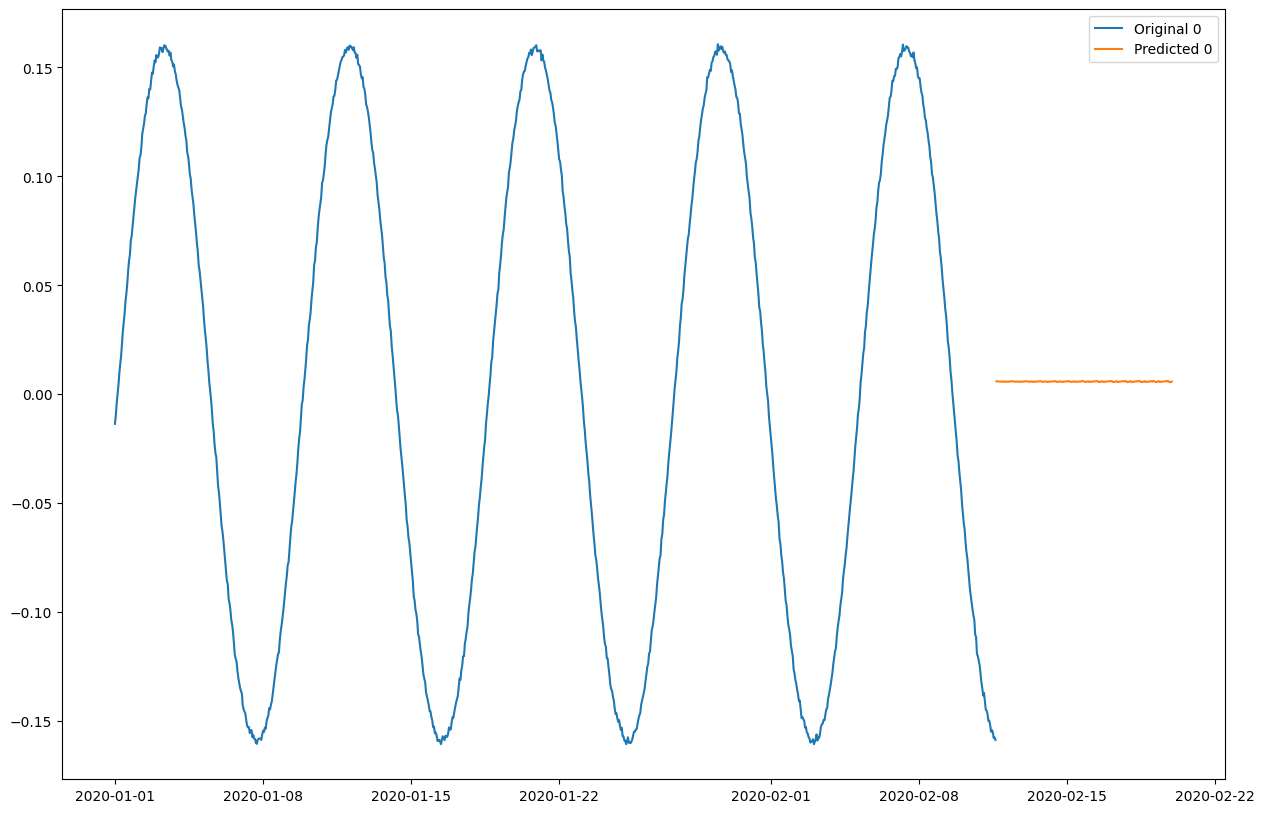

In [35]:
# plot the original values and predictions for the first 5 time series from the first batch
plt.figure(figsize=(15, 10))
for i in range(1):
    item_id = str(i)
    item_df = first_batch_df[first_batch_df["item_id"] == item_id]
    pred_item_df = pred_df[pred_df["item_id"] == item_id]
    # print(pred_item_df.head())
    
    plt.plot(item_df["timestamp"], item_df["target"], label=f"Original {item_id}")
    plt.plot(pred_item_df["timestamp"], pred_item_df["predictions"], label=f"Predicted {item_id}")
plt.legend()
plt.show()